In [13]:
import os
# Create figures folder if it doesn't exist
os.makedirs('figures', exist_ok=True)
FIGURES_DIR = 'figures'

# Part 1: Policy Evaluation (Dynamic Programming)

## Q1.1, Q1.2, Q1.3: Iterative Policy Evaluation

This notebook covers:
- **Q1.1**: Iterative policy evaluation on 4×4 grid
- **Q1.2**: Parameter sensitivity analysis (grid size, discount factor, threshold)
- **Q1.3**: Deterministic vs Stochastic dynamics comparison

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld import GridWorld
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Helper Function: Iterative Policy Evaluation

In [15]:
def iterative_policy_evaluation(env, gamma=1.0, theta=0.01, max_iterations=1000):
    """
    Compute the value function for a given policy using iterative policy evaluation.
    
    Uses Bellman expectation equation:
    V(s) = Σ_a π(a|s) Σ_{s',r} P(s',r|s,a)[r + γV(s')]
    """
    V = np.zeros(env.n_states)
    deltas = []
    
    for iteration in range(max_iterations):
        V_old = V.copy()
        
        for s in range(env.n_states):
            if env.is_terminal(s):
                V[s] = 0.0
            else:
                value_sum = 0.0
                for action in range(env.n_actions):
                    action_prob = env.policy[s, action]
                    transitions = env.get_transitions(s, action)
                    
                    for prob, next_state, reward, done in transitions:
                        if done:
                            value_sum += action_prob * prob * reward
                        else:
                            value_sum += action_prob * prob * (reward + gamma * V_old[next_state])
                
                V[s] = value_sum
        
        delta = np.max(np.abs(V - V_old))
        deltas.append(delta)
        
        if delta < theta:
            return V, iteration + 1, deltas
    
    return V, max_iterations, deltas

---
# Q1.1: Iterative Policy Evaluation

**Setup:**
- Grid: 4×4
- Terminal states: top-left (0) and bottom-right (15)
- Discount factor: γ = 1 (episodic)
- Policy: equiprobable random
- Convergence threshold: θ = 0.01

In [16]:
# Create 4×4 gridworld
env = GridWorld(N=4, terminal_states={0, 15})
print(f"Environment: {env}")
print(f"Terminal states: {env.terminal_states}")
print(f"Policy: Equiprobable (0.25 per action)\n")

# Run policy evaluation
theta = 0.01
V, num_iterations, deltas = iterative_policy_evaluation(env, gamma=1.0, theta=theta)

print(f"Convergence in {num_iterations} iterations (θ={theta})")
print(f"\nFinal Value Function V(s) - Displayed as 4×4 Grid:")
env.render_values(V)

Environment: GridWorld(4×4, n_states=16, terminal_states={0, 15}, stochastic=False)
Terminal states: frozenset({0, 15})
Policy: Equiprobable (0.25 per action)

Convergence in 89 iterations (θ=0.01)

Final Value Function V(s) - Displayed as 4×4 Grid:
0.00  -13.90  -19.84  -21.83
-13.90  -17.86  -19.85  -19.84
-19.84  -19.85  -17.86  -13.90
-21.83  -19.84  -13.90  0.00


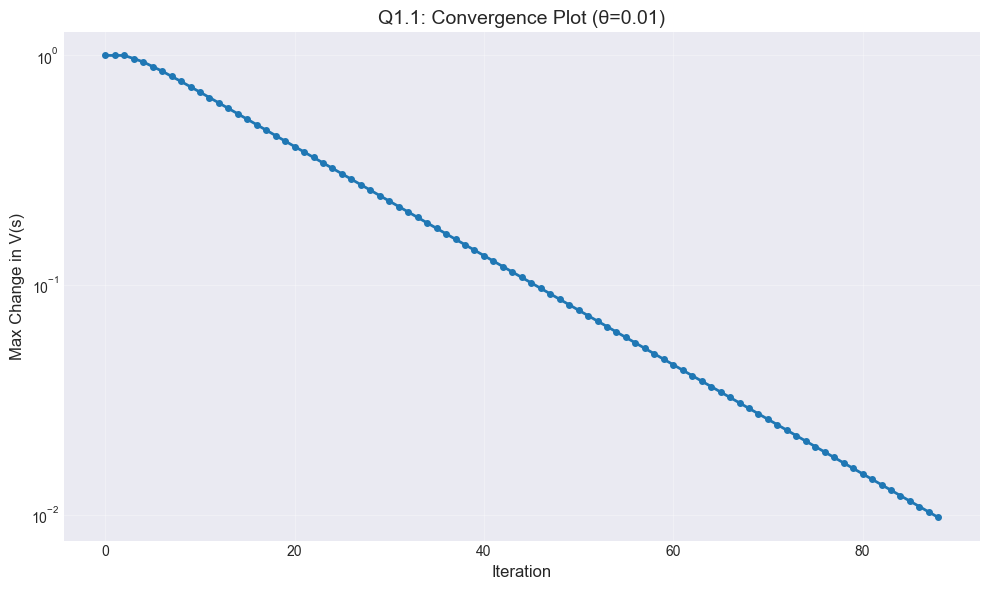


✓ Q1.1 Deliverables:
  1. Final value function (printed above)
  2. Iterations to converge: 89
  3. Convergence plot saved


In [17]:
# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(deltas, marker='o', markersize=4, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Max Change in V(s)', fontsize=12)
plt.title(f'Q1.1: Convergence Plot (θ={theta})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'q1_1_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Q1.1 Deliverables:")
print(f"  1. Final value function (printed above)")
print(f"  2. Iterations to converge: {num_iterations}")
print(f"  3. Convergence plot saved")

---
# Q1.2: Parameter Sensitivity Analysis

**Vary:**
- Grid sizes: N = 4, 5, 10
- Discount factors: γ = 1, 0.9, 0.5
- Thresholds: θ = 10⁻², 10⁻⁶

**Analyze:** Effect on convergence and value magnitudes

In [18]:
# Run experiments
grid_sizes = [4, 5, 10]
gammas = [1.0, 0.9, 0.5]
thetas = [1e-2, 1e-6]

results = {}

print("Running parameter sensitivity experiments...\n")

for N in grid_sizes:
    print(f"Grid size N={N}:")
    env = GridWorld(N=N, terminal_states={0, N*N - 1})
    
    for gamma in gammas:
        for theta in thetas:
            print(f"  γ={gamma}, θ={theta:.0e}...", end=" ")
            
            V, iterations, deltas = iterative_policy_evaluation(
                env, gamma=gamma, theta=theta, max_iterations=5000
            )
            
            key = f"N{N}_gamma{gamma}_theta{theta:.0e}"
            results[key] = {'iterations': iterations, 'deltas': deltas, 'gamma': gamma, 'theta': theta, 'N': N}
            print(f"✓ ({iterations} iter)")
    print()

Running parameter sensitivity experiments...

Grid size N=4:
  γ=1.0, θ=1e-02... ✓ (89 iter)
  γ=1.0, θ=1e-06... ✓ (258 iter)
  γ=0.9, θ=1e-02... ✓ (31 iter)
  γ=0.9, θ=1e-06... ✓ (89 iter)
  γ=0.5, θ=1e-02... ✓ (8 iter)
  γ=0.5, θ=1e-06... ✓ (20 iter)

Grid size N=5:
  γ=1.0, θ=1e-02... ✓ (169 iter)
  γ=1.0, θ=1e-06... ✓ (493 iter)
  γ=0.9, θ=1e-02... ✓ (37 iter)
  γ=0.9, θ=1e-06... ✓ (106 iter)
  γ=0.5, θ=1e-02... ✓ (8 iter)
  γ=0.5, θ=1e-06... ✓ (21 iter)

Grid size N=10:
  γ=1.0, θ=1e-02... ✓ (1065 iter)
  γ=1.0, θ=1e-06... ✓ (3126 iter)
  γ=0.9, θ=1e-02... ✓ (45 iter)
  γ=0.9, θ=1e-06... ✓ (129 iter)
  γ=0.5, θ=1e-02... ✓ (8 iter)
  γ=0.5, θ=1e-06... ✓ (21 iter)



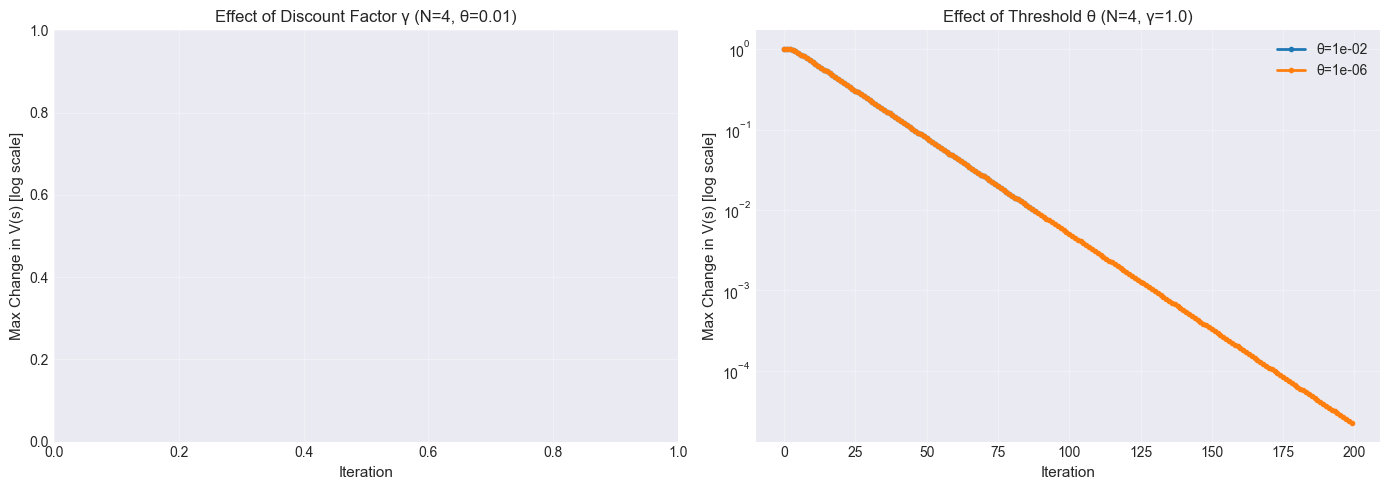

In [19]:
# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of γ
ax = axes[0]
for gamma in gammas:
    key = f"N4_gamma{gamma}_theta0.01e+00"
    if key in results:
        deltas = results[key]['deltas']
        ax.semilogy(deltas, marker='o', markersize=3, label=f'γ={gamma}', linewidth=2)

ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Max Change in V(s) [log scale]', fontsize=11)
ax.set_title('Effect of Discount Factor γ (N=4, θ=0.01)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Effect of θ
ax = axes[1]
for theta in thetas:
    key = f"N4_gamma1.0_theta{theta:.0e}"
    if key in results:
        deltas = results[key]['deltas'][:200]  # Truncate for visibility
        theta_label = f'θ={theta:.0e}'
        ax.semilogy(deltas, marker='o', markersize=3, label=theta_label, linewidth=2)

ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Max Change in V(s) [log scale]', fontsize=11)
ax.set_title('Effect of Threshold θ (N=4, γ=1.0)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'q1_2_parameter_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Summary table
print("\n" + "="*70)
print("Q1.2: Parameter Sensitivity - Iteration Counts")
print("="*70)
print(f"\n{'N':<5} {'γ':<8} {'θ':<15} {'Iterations':<15}")
print("-" * 50)

for N in grid_sizes:
    for gamma in gammas:
        for theta in thetas:
            key = f"N{N}_gamma{gamma}_theta{theta:.0e}"
            if key in results:
                iterations = results[key]['iterations']
                print(f"{N:<5} {gamma:<8.1f} {theta:<15.0e} {iterations:<15d}")

print("\n✓ Q1.2 Deliverables:")
print("  1. Comparative convergence curves")
print("  2. Analysis of parameter effects on convergence")


Q1.2: Parameter Sensitivity - Iteration Counts

N     γ        θ               Iterations     
--------------------------------------------------
4     1.0      1e-02           89             
4     1.0      1e-06           258            
4     0.9      1e-02           31             
4     0.9      1e-06           89             
4     0.5      1e-02           8              
4     0.5      1e-06           20             
5     1.0      1e-02           169            
5     1.0      1e-06           493            
5     0.9      1e-02           37             
5     0.9      1e-06           106            
5     0.5      1e-02           8              
5     0.5      1e-06           21             
10    1.0      1e-02           1065           
10    1.0      1e-06           3126           
10    0.9      1e-02           45             
10    0.9      1e-06           129            
10    0.5      1e-02           8              
10    0.5      1e-06           21             

✓ Q1.2

**Key Findings:**
- **γ effect**: Larger γ accumulates rewards more → larger values, slower propagation
- **Grid size**: Larger grids → more states → slower value propagation
- **θ effect**: Smaller θ requires more iterations, exponential relationship

---
# Q1.3: Stochastic Dynamics Comparison

**Compare:**
- Deterministic: actions go to intended state
- Stochastic: intended 0.8, perpendicular 0.1 each

In [21]:
# Run for deterministic and stochastic
print("Computing value functions...\n")

env_det = GridWorld(N=4, terminal_states={0, 15}, stochastic=False)
V_det, iter_det, deltas_det = iterative_policy_evaluation(env_det, gamma=1.0, theta=1e-2)
print(f"Deterministic: Converged in {iter_det} iterations")

env_sto = GridWorld(N=4, terminal_states={0, 15}, stochastic=True, slip_prob=0.1)
V_sto, iter_sto, deltas_sto = iterative_policy_evaluation(env_sto, gamma=1.0, theta=1e-2)
print(f"Stochastic: Converged in {iter_sto} iterations")

Computing value functions...

Deterministic: Converged in 89 iterations
Stochastic: Converged in 89 iterations


In [22]:
# Display value functions
print("\n" + "="*70)
print("DETERMINISTIC Value Function:")
print("="*70)
env_det.render_values(V_det)

print("\n" + "="*70)
print("STOCHASTIC Value Function:")
print("="*70)
env_sto.render_values(V_sto)

print("\n" + "="*70)
print("DIFFERENCE: V_stochastic(s) - V_deterministic(s)")
print("="*70)
V_diff = V_sto - V_det
env_det.render_values(V_diff)


DETERMINISTIC Value Function:
0.00  -13.90  -19.84  -21.83
-13.90  -17.86  -19.85  -19.84
-19.84  -19.85  -17.86  -13.90
-21.83  -19.84  -13.90  0.00

STOCHASTIC Value Function:
0.00  -13.90  -19.84  -21.83
-13.90  -17.86  -19.85  -19.84
-19.84  -19.85  -17.86  -13.90
-21.83  -19.84  -13.90  0.00

DIFFERENCE: V_stochastic(s) - V_deterministic(s)
0.00  -0.00  -0.00  -0.00
-0.00  -0.00  -0.00  -0.00
-0.00  -0.00  -0.00  -0.00
-0.00  -0.00  -0.00  0.00


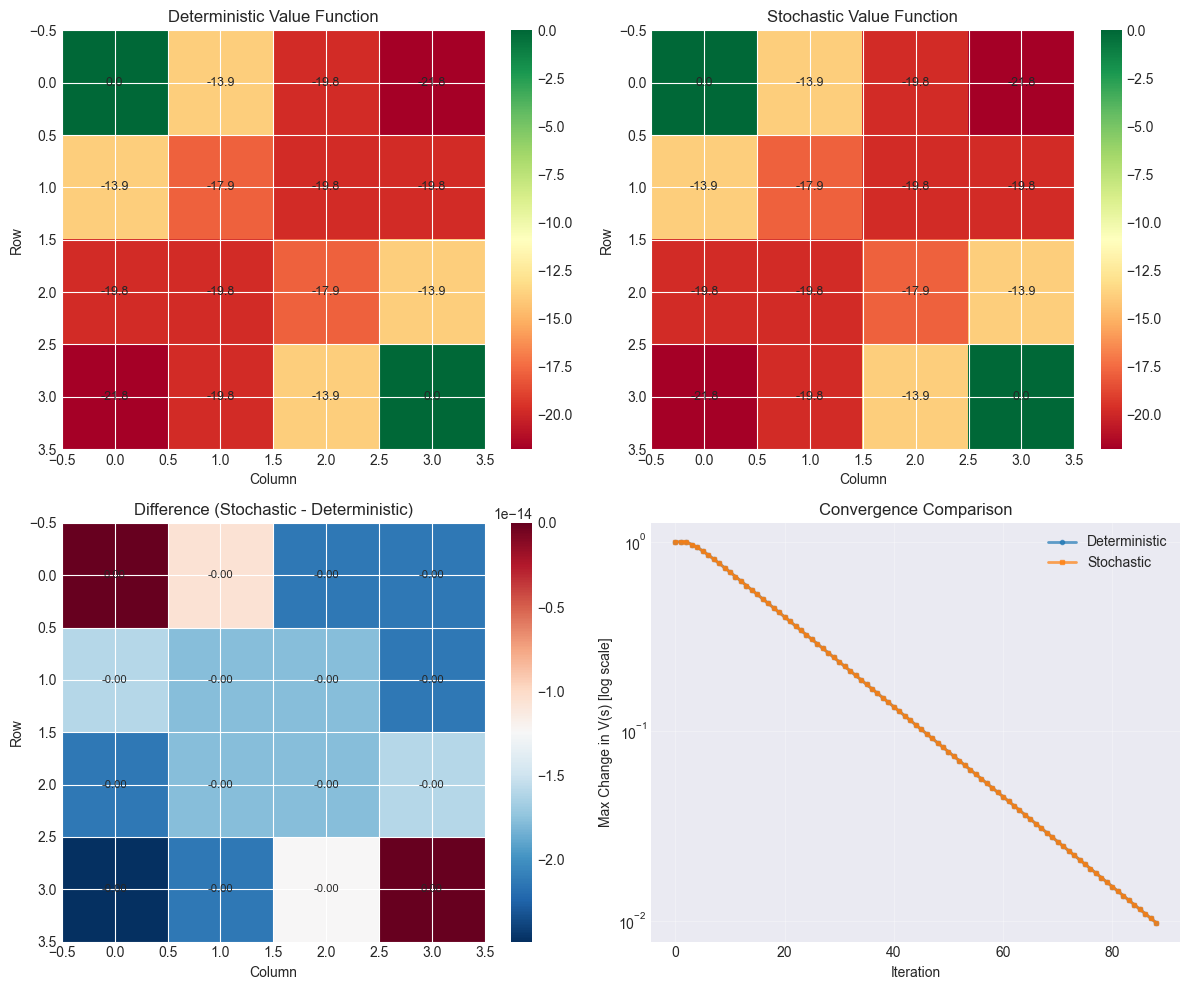

In [23]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Heatmap: Deterministic
ax = axes[0, 0]
V_det_grid = V_det.reshape(4, 4)
im1 = ax.imshow(V_det_grid, cmap='RdYlGn', aspect='auto')
ax.set_title('Deterministic Value Function', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{V_det_grid[i, j]:.1f}', ha='center', va='center', fontsize=9)
plt.colorbar(im1, ax=ax)

# Heatmap: Stochastic
ax = axes[0, 1]
V_sto_grid = V_sto.reshape(4, 4)
im2 = ax.imshow(V_sto_grid, cmap='RdYlGn', aspect='auto')
ax.set_title('Stochastic Value Function', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{V_sto_grid[i, j]:.1f}', ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=ax)

# Heatmap: Difference
ax = axes[1, 0]
V_diff_grid = V_diff.reshape(4, 4)
im3 = ax.imshow(V_diff_grid, cmap='RdBu_r', aspect='auto')
ax.set_title('Difference (Stochastic - Deterministic)', fontsize=12)
ax.set_xlabel('Column')
ax.set_ylabel('Row')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{V_diff_grid[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im3, ax=ax)

# Convergence comparison
ax = axes[1, 1]
ax.semilogy(deltas_det, marker='o', markersize=3, label='Deterministic', alpha=0.7, linewidth=2)
ax.semilogy(deltas_sto, marker='s', markersize=3, label='Stochastic', alpha=0.7, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Max Change in V(s) [log scale]')
ax.set_title('Convergence Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'q1_3_stochastic_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Statistics
print("\n" + "="*70)
print("Q1.3: Statistics")
print("="*70)

print(f"\nConvergence:")
print(f"  Deterministic: {iter_det} iterations")
print(f"  Stochastic:    {iter_sto} iterations")

print(f"\nValue Statistics:")
print(f"  Deterministic - Min: {V_det.min():.4f}, Max: {V_det.max():.4f}, Mean: {V_det.mean():.4f}")
print(f"  Stochastic    - Min: {V_sto.min():.4f}, Max: {V_sto.max():.4f}, Mean: {V_sto.mean():.4f}")

print(f"\nDifference:")
print(f"  Min:  {V_diff.min():.4f}")
print(f"  Max:  {V_diff.max():.4f}")
print(f"  Mean: {V_diff.mean():.4f}")
print(f"  Std:  {V_diff.std():.4f}")

print("\n✓ Q1.3 Deliverables:")
print("  1. Value function grids (deterministic and stochastic)")
print("  2. Difference heatmap")
print("  3. Convergence comparison plot")


Q1.3: Statistics

Convergence:
  Deterministic: 89 iterations
  Stochastic:    89 iterations

Value Statistics:
  Deterministic - Min: -21.8264, Max: 0.0000, Mean: -15.8770
  Stochastic    - Min: -21.8264, Max: 0.0000, Mean: -15.8770

Difference:
  Min:  -0.0000
  Max:  0.0000
  Mean: -0.0000
  Std:  0.0000

✓ Q1.3 Deliverables:
  1. Value function grids (deterministic and stochastic)
  2. Difference heatmap
  3. Convergence comparison plot
